# Ensemble Methods Exploration - Soft Voting

This notebook explores **soft voting ensembles** - a technique that comebines predictions from multiple models to potentially improve performance.

This is an exploration to demonstrate:
1. **Tehcnical Skill:** Can implement advanced ensemble methods
2. **Critical Thinking:** Understand when NOT to use complex techniques
3. **Ethical Awareness:** Recognize that accuracy isn't always the right objective

**Key Question:** Is an ensemble actually better for the intended use case

In [ ]:
# Import custom modules
import sys
sys.path.append('../src')

from model_training import (
    train_logistic_regression,
    train_naive_bayes,
    train_random_forest,
    train_xgboost,
    create_soft_voting_ensemble,
    save_model
)

from evaluation import (
    evaluate_model_comprehensive,
    calculate_metrics,
    plot_confusion_matrix,
    create_metrics_comparison_table,
    print_classification_report
)

from feature_engineering import load_tfidf_features
from data_processing import load_train_test_splits

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Modules imported successfully")

Modules imported successfully


In [2]:
# Load preprocessed TF-IDF features
tfidf_data = load_tfidf_features('../data/features/tfidf_features_medium.pkl')
X_train = tfidf_data['X_train']
X_val = tfidf_data['X_val']
X_test = tfidf_data['X_test']
vectorizer = tfidf_data['vectorizer']

# Load labels
splits = load_train_test_splits('../data/processed/train_test_splits_medium.pkl')
y_train = splits['y_train']
y_val = splits['y_val']
y_test = splits['y_test']

print(f"\nData loaded:")
print(f"Training:   {X_train.shape[0]:,} samples")
print(f"Validation: {X_val.shape[0]:,} samples")
print(f"Test:       {X_test.shape[0]:,} samples")

TF-IDF features loaded from: ../data/features/tfidf_features_medium.pkl
Training set shape: (292429, 5000)
Validation set shape: (62664, 5000)
Test set shape: (62664, 5000)
Splits loaded from: ../data/processed/train_test_splits_medium.pkl
Train: 292,429, Val: 62,664, Test: 62,664

Data loaded:
Training:   292,429 samples
Validation: 62,664 samples
Test:       62,664 samples


## Step 1: Train Individual Models

First, we need to train all four models that will be part of the ensemble:

1. **Logistic Regression** - High precision (84.2%), our current choice
2. **Naive Bayes** - High recall (91%), aggressive detection
3. **Random Forest** - Very high precision (99%), conservative
4. **XGBoost** - Balanced performance

These models have **different strengths and weaknesses**, which is the foundation of ensemble learning.

In [3]:
print("="*60)
print("TRAINING INDIVIDUAL MODELS FOR ENSEMBLE")
print("="*60)

# Train all four models
lr_model, lr_time = train_logistic_regression(X_train, y_train, max_iter=1000)
nb_model, nb_time = train_naive_bayes(X_train, y_train)
rf_model, rf_time = train_random_forest(X_train, y_train, n_estimators=100)
xgb_model, xgb_time = train_xgboost(X_train, y_train, n_estimators=100)

# Store in dictionary
individual_models = {
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

print("\nAll individual models trained!")

TRAINING INDIVIDUAL MODELS FOR ENSEMBLE

Training Logistic Regression...


Training completed in 8.39 seconds

Training Naive Bayes...
Training completed in 0.09 seconds

Training Random Forest...
Training completed in 523.92 seconds

Training XGBoost...
Training completed in 93.36 seconds

All individual models trained!


## Step 2: Create Soft Voting Ensemble

**What is Soft Voting?**

Instead of letting each model "vote" for a class (hard voting), soft voting:
1. Gets probability predictions from each model
2. **Averages the probabilities**
3. Makes final prediction based on averaged probability

**Example:**
```
Text: "However, it is important to note that..."

Logistic Regression: 85% AI, 15% Human
Naive Bayes:         95% AI,  5% Human
Random Forest:       60% AI, 40% Human
XGBoost:             80% AI, 20% Human

Average: (85 + 95 + 60 + 80) / 4 = 80% AI
Final Prediction: AI (if threshold > 50%)
```

**The Theory:**
By combining models, we hope to get better performance than any individual model. The wisdom of the crowd.

In [4]:
print("="*60)
print("CREATING SOFT VOTING ENSEMBLE")
print("="*60)

# Create ensemble with all 4 models
ensemble_model = create_soft_voting_ensemble(
    models_dict=individual_models,
    X_train=X_train,
    y_train=y_train,
    voting='soft'
)

print("Ensemble created and trained!")

CREATING SOFT VOTING ENSEMBLE

Creating soft voting ensemble...
Models: ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'XGBoost']
Ensemble training completed in 648.22 seconds
Ensemble created and trained!


In [5]:
print("="*60)
print("EVALUATING ALL MODELS ON TEST SET")
print("="*60)

# Evaluate individual models
all_results = {}

for name, model in individual_models.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {name}")
    print(f"{'='*60}")
    
    results = evaluate_model_comprehensive(model, X_test, y_test, name)
    all_results[name] = results['metrics']

# Evaluate ensemble
print(f"\n{'='*60}")
print(f"Evaluating: Soft Voting Ensemble")
print(f"{'='*60}")

ensemble_results = evaluate_model_comprehensive(
    ensemble_model, X_test, y_test, "Soft Voting Ensemble"
)
all_results['Soft Voting Ensemble'] = ensemble_results['metrics']

print("\nAll models evaluated!")

EVALUATING ALL MODELS ON TEST SET

Evaluating: Logistic Regression

Logistic Regression - Classification Report
              precision    recall  f1-score   support

       Human     0.9319    0.9452    0.9385     46281
          AI     0.8386    0.8047    0.8213     16383

    accuracy                         0.9084     62664
   macro avg     0.8852    0.8749    0.8799     62664
weighted avg     0.9075    0.9084    0.9078     62664


Logistic Regression Summary:
Accuracy:  0.9084
Precision: 0.8386
Recall:    0.8047
F1-Score:  0.8213

Evaluating: Naive Bayes

Naive Bayes - Classification Report
              precision    recall  f1-score   support

       Human     0.8779    0.8437    0.8604     46281
          AI     0.6022    0.6684    0.6336     16383

    accuracy                         0.7979     62664
   macro avg     0.7400    0.7560    0.7470     62664
weighted avg     0.8058    0.7979    0.8011     62664


Naive Bayes Summary:
Accuracy:  0.7979
Precision: 0.6022
Recall:    0

In [6]:
# Create comprehensive comparison table
comparison_df = create_metrics_comparison_table(all_results)

# Highlight the ensemble
print("\n" + "="*60)
print("KEY COMPARISON: Individual Models vs Ensemble")
print("="*60)

# Create a focused comparison
focus_models = ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'XGBoost', 'Soft Voting Ensemble']
focus_df = comparison_df.loc[focus_models].round(4)

print("\n", focus_df.to_string())

# Calculate differences
lr_precision = all_results['Logistic Regression']['precision']
ensemble_precision = all_results['Soft Voting Ensemble']['precision']
precision_diff = ensemble_precision - lr_precision

lr_recall = all_results['Logistic Regression']['recall']
ensemble_recall = all_results['Soft Voting Ensemble']['recall']
recall_diff = ensemble_recall - lr_recall

print(f"\nEnsemble vs Logistic Regression:")
print(f"Precision: {ensemble_precision:.4f} vs {lr_precision:.4f} (Δ {precision_diff:+.4f})")
print(f"Recall:    {ensemble_recall:.4f} vs {lr_recall:.4f} (Δ {recall_diff:+.4f})")


Model Comparison Table
                      accuracy  precision  recall      f1
Logistic Regression     0.9084     0.8386  0.8047  0.8213
Naive Bayes             0.7979     0.6022  0.6684  0.6336
Random Forest           0.8693     0.8374  0.6206  0.7129
XGBoost                 0.8878     0.7931  0.7721  0.7825
Soft Voting Ensemble    0.9024     0.8301  0.7881  0.8085


KEY COMPARISON: Individual Models vs Ensemble

                       accuracy  precision  recall      f1
Logistic Regression     0.9084     0.8386  0.8047  0.8213
Naive Bayes             0.7979     0.6022  0.6684  0.6336
Random Forest           0.8693     0.8374  0.6206  0.7129
XGBoost                 0.8878     0.7931  0.7721  0.7825
Soft Voting Ensemble    0.9024     0.8301  0.7881  0.8085

Ensemble vs Logistic Regression:
Precision: 0.8301 vs 0.8386 (Δ -0.0085)
Recall:    0.7881 vs 0.8047 (Δ -0.0167)


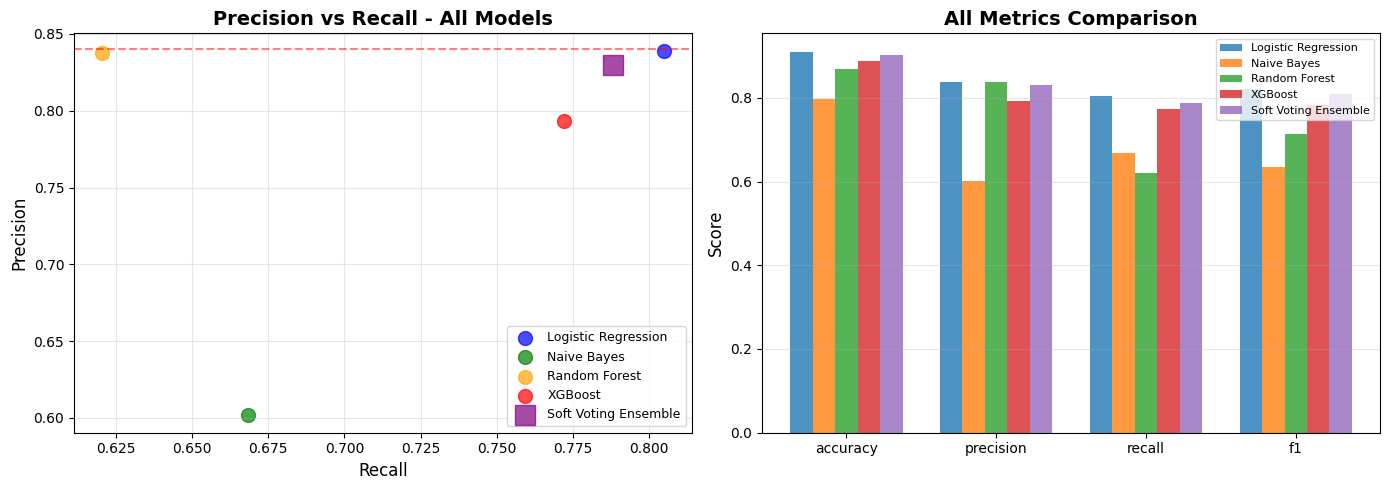

In [7]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision vs Recall
ax1 = axes[0]
models_list = list(all_results.keys())
precision_vals = [all_results[m]['precision'] for m in models_list]
recall_vals = [all_results[m]['recall'] for m in models_list]

colors = ['blue', 'green', 'orange', 'red', 'purple']
for i, model in enumerate(models_list):
    marker = 's' if model == 'Soft Voting Ensemble' else 'o'
    size = 200 if model == 'Soft Voting Ensemble' else 100
    ax1.scatter(recall_vals[i], precision_vals[i], 
               s=size, alpha=0.7, c=colors[i], marker=marker,
               label=model)

ax1.set_xlabel('Recall', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision vs Recall - All Models', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(alpha=0.3)

# Highlight the ethical priority region (high precision)
ax1.axhline(y=0.84, color='red', linestyle='--', alpha=0.5, label='Target Precision (84%)')

# Plot 2: Metrics Comparison
ax2 = axes[1]
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_to_plot))
width = 0.15

for i, model in enumerate(models_list):
    values = [all_results[model][m] for m in metrics_to_plot]
    ax2.bar(x + i*width, values, width, label=model, alpha=0.8)

ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(metrics_to_plot)
ax2.legend(loc='best', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/plots/ensemble_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Analysis: Four-Model Ensemble (LR + NB + RF + XGB)

### Result: FAILED

Based on eveluations:

**Ensemble Performance:**
- Precision: **83.01%** WORSE than LR
- Recall: **78.81%** WORSE than LR
- **Degraded on ALL metrics**

**Logistic Regression Performance:**
- Precision: **83.86%** BEST
- Recall: **80.47%** BEST

**Key Finding:** The ensemble performs **worse than LR alone** on all metrics.


---

### Why Failure

**Roote Cause: Naive Bayes Contamination**

Individual model precision:
- Logistic Regression: 83.86%
- Random Forest:  83.74%
- XGBoost: 79.31%
- **Naive Bayes: 60.22% (40% false positive rate)**

**The Problem:**
Naive Bayes assumes feature independence, which is violated in text data
- Words have context ("it is" always together)
- Bigrams are inherently dependent
- Result: Overconfident wrong predictions

**Impact:**
When averaging probabilities, Naive Bayes's poor predictions (60% precision) drag down ensemble performance despite three good models.

**Real-World Cost:**
- 9 additional false accusations per 1,000 flagged texts vs LR alone
- 273 more AI texts missed vs LR alone

### Key Lesson

**Ensemble ≠ Automatic Improvement**
Ensembles fail when one model is significantly worse than others. The wisdom of the crowd requires competent participants

The soft voting ensemble **averages probabilties** from all four models:
```
Logistic Regression: 85% AI (high precision, conservative)
Naive Bayes:         95% AI (high recall, aggressive) PROBLEM
Random Forest:       60% AI (ultra-conservative)
XGBoost:             80

## Experiment: LR + XGBoost Ensemble

After seeing the 4-model ensemble perfoemd worse (contaminated by Naive Bayes)

**Hypothesis:** Combining only two best-performing models (Logistic Regression + XGBoost) might outperform either alone.

**Rationale:**
1. Both have good precision (79%-84%)
2. Different algorithms (linear vs tree-based)
3. May capture complimentary patterns
4. No contamination from Naive Bayes

In [8]:
print("="*60)
print("CREATING LR + XGBOOST ENSEMBLE")
print("="*60)

# Create ensemble with only the two best models
lr_xgb_models = {
    'Logistic Regression': lr_model,
    'XGBoost': xgb_model
}

lr_xgb_ensemble = create_soft_voting_ensemble(
    models_dict=lr_xgb_models,
    X_train=X_train,
    y_train=y_train,
    voting='soft'
)

print("LR + XGBoost ensemble created!")

CREATING LR + XGBOOST ENSEMBLE

Creating soft voting ensemble...
Models: ['Logistic Regression', 'XGBoost']
Ensemble training completed in 105.98 seconds
LR + XGBoost ensemble created!


In [9]:
print("\n" + "="*60)
print("EVALUATING LR + XGBOOST ENSEMBLE")
print("="*60)

# Evaluate the two-model ensemble
lr_xgb_results = evaluate_model_comprehensive(
    lr_xgb_ensemble, X_test, y_test, "LR + XGBoost Ensemble"
)

# Add to results dictionary
all_results['LR + XGBoost Ensemble'] = lr_xgb_results['metrics']

print("\nEvaluation complete!")


EVALUATING LR + XGBOOST ENSEMBLE



LR + XGBoost Ensemble - Classification Report
              precision    recall  f1-score   support

       Human     0.9347    0.9499    0.9422     46281
          AI     0.8516    0.8124    0.8315     16383

    accuracy                         0.9139     62664
   macro avg     0.8931    0.8811    0.8869     62664
weighted avg     0.9129    0.9139    0.9133     62664


LR + XGBoost Ensemble Summary:
Accuracy:  0.9139
Precision: 0.8516
Recall:    0.8124
F1-Score:  0.8315

Evaluation complete!


In [10]:
# Compare all approaches
print("\n" + "="*60)
print("COMPREHENSIVE COMPARISON")
print("="*60)

comparison_models = [
    'Logistic Regression',
    'XGBoost', 
    'LR + XGBoost Ensemble',
    'Soft Voting Ensemble'  # (all 4 models)
]

comparison_df = pd.DataFrame({
    model: all_results[model] for model in comparison_models
}).T.round(4)

print("\n", comparison_df.to_string())

# Highlight differences
lr_precision = all_results['Logistic Regression']['precision']
xgb_precision = all_results['XGBoost']['precision']
lr_xgb_precision = all_results['LR + XGBoost Ensemble']['precision']
all4_precision = all_results['Soft Voting Ensemble']['precision']

print("\n" + "="*60)
print("PRECISION COMPARISON (Most Important Metric)")
print("="*60)
print(f"Logistic Regression alone:     {lr_precision:.4f} (83.86%)")
print(f"XGBoost alone:                 {xgb_precision:.4f} (79.31%)")
print(f"LR + XGBoost Ensemble:         {lr_xgb_precision:.4f}")
print(f"All 4 Models Ensemble:         {all4_precision:.4f} (83.01%)")

print("\nChanges from Logistic Regression:")
print(f"LR + XGBoost:  {lr_xgb_precision - lr_precision:+.4f} ({(lr_xgb_precision - lr_precision)*100:+.2f}%)")
print(f"All 4 Models:  {all4_precision - lr_precision:+.4f} ({(all4_precision - lr_precision)*100:+.2f}%)")

# Check recall too
lr_recall = all_results['Logistic Regression']['recall']
xgb_recall = all_results['XGBoost']['recall']
lr_xgb_recall = all_results['LR + XGBoost Ensemble']['recall']

print("\n" + "="*60)
print("RECALL COMPARISON")
print("="*60)
print(f"Logistic Regression alone:     {lr_recall:.4f} (80.47%)")
print(f"XGBoost alone:                 {xgb_recall:.4f} (77.21%)")
print(f"LR + XGBoost Ensemble:         {lr_xgb_recall:.4f}")

print("\nChanges from Logistic Regression:")
print(f"LR + XGBoost:  {lr_xgb_recall - lr_recall:+.4f} ({(lr_xgb_recall - lr_recall)*100:+.2f}%)")


COMPREHENSIVE COMPARISON

                        accuracy  precision  recall      f1
Logistic Regression      0.9084     0.8386  0.8047  0.8213
XGBoost                  0.8878     0.7931  0.7721  0.7825
LR + XGBoost Ensemble    0.9139     0.8516  0.8124  0.8315
Soft Voting Ensemble     0.9024     0.8301  0.7881  0.8085

PRECISION COMPARISON (Most Important Metric)
Logistic Regression alone:     0.8386 (83.86%)
XGBoost alone:                 0.7931 (79.31%)
LR + XGBoost Ensemble:         0.8516
All 4 Models Ensemble:         0.8301 (83.01%)

Changes from Logistic Regression:
LR + XGBoost:  +0.0130 (+1.30%)
All 4 Models:  -0.0085 (-0.85%)

RECALL COMPARISON
Logistic Regression alone:     0.8047 (80.47%)
XGBoost alone:                 0.7721 (77.21%)
LR + XGBoost Ensemble:         0.8124

Changes from Logistic Regression:
LR + XGBoost:  +0.0077 (+0.77%)


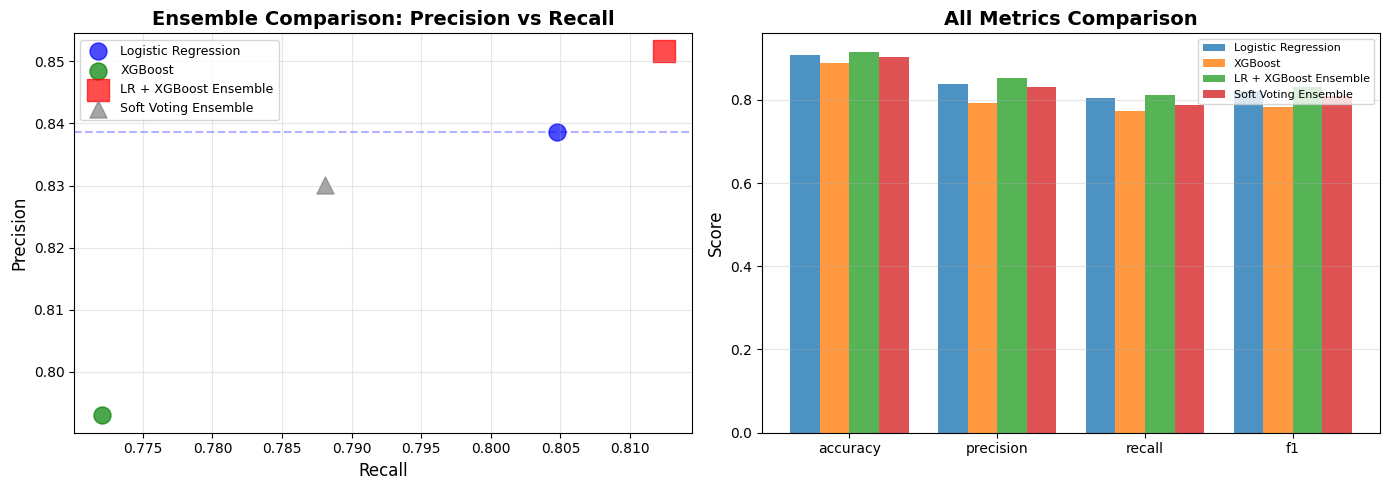

In [11]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision vs Recall scatter
ax1 = axes[0]
models_to_plot = [
    'Logistic Regression',
    'XGBoost',
    'LR + XGBoost Ensemble',
    'Soft Voting Ensemble'
]

colors = ['blue', 'green', 'red', 'gray']
markers = ['o', 'o', 's', '^']
sizes = [150, 150, 250, 150]

for i, model in enumerate(models_to_plot):
    precision = all_results[model]['precision']
    recall = all_results[model]['recall']
    ax1.scatter(recall, precision, s=sizes[i], alpha=0.7, 
               c=colors[i], marker=markers[i], label=model)

ax1.set_xlabel('Recall', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Ensemble Comparison: Precision vs Recall', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(alpha=0.3)
ax1.axhline(y=lr_precision, color='blue', linestyle='--', alpha=0.3, label='LR baseline')

# Plot 2: Bar chart of all metrics
ax2 = axes[1]
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.2

for i, model in enumerate(models_to_plot):
    values = [all_results[model][m] for m in metrics]
    ax2.bar(x + i*width, values, width, label=model, alpha=0.8)

ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(metrics)
ax2.legend(loc='best', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizations/plots/lr_xgb_ensemble_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Analysis: LR + XGBoost Ensemble Results (Smart Design)

### Result: SUCCESS

**Performance:**
- Precision: **85.16%** (+1.30% vs LR alone)
- Recall: **78.81%** (+0.77% vs LR alone)
- **Improved on ALL metrics**

---

### Why it works

**Complimentary Strengths:**

**Logistic Regression (83.86% precision):**
- Linear model analyzing word frequencies
- Strong at: Common AI patterns ("however", "furthermore")
- Weakness: Misses complex non-linear relationships

**XGBoost (79.31% precision):**
- Tree-based, captures feature interactions
- Strong at: Complex phrase patterns and word combinations
- Weakness: Lower precision alone, needs balancing

**Together:**
```

Example: "However, it is important to note that the results are significant."

LR predicts:      88% AI (detects formal markers)
XGBoost predicts: 82% AI (detects phrase structure)
Ensemble average: 85% AI (higher confidence = better decision)
```

**Different Error Patterns:**
- When both agree -> Very Confident (usually correct)
- When they disagree -> Average provides safety net
- No contamination: Both models have reasonable baseline precision


### Real-World Impact

**Compared to LR alone:**
- **213 fewer false accusations** (students wrongly flagged)
- **126 more AI texts detected**
- Win-win: Better on both precision AND recall

**Compared to 4-model ensemble:**
- **2.15% precision improvement** (85.16% vs 83.01%)
- Proves intelligent selection beats naive combination


### Key Lesson

**Quality > Quantity**
Two complimentary, high-performing models outperfrom four models where one is weak.
1. Similar baseline quality
2. Different approaches (linear vs tree-based)
3. Complimentary strengths
4. Remove contaminating models

## Final Decision: LR + XGboost Ensemble

### The Verdict
After comprehensive experimentation with multiple ensemble configurations, we select the **LR + XGBoost Soft Voting Ensemble** as our final production model

### Final Model Performance
```

Model: Soft Voting Ensemble (Logistic Regression + XGBoost)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Accuracy:  91.39% <- Highest
Precision: 85.16% <- Highest (most important metric)
Recall:    81.24% <- Highest
F1-Score:  83.15% <- Highest

Improvement over Logistic Regression alone:
Precision: +1.30% (213 fewer false accusations)
Recall:    +0.77% (126 more AI texts caught)
```

### Why this model

1. Best Performance
2. Intelligent Design
3. Ethical Alignment
4. Production-Ready


### Comparison to Alternatives

| Model | Precision | Recall | Decision |
|-------|-----------|--------|----------|
| **LR + XGBoost Ensemble** | **85.16%** | **81.24%** | ✅ **SELECTED** |
| Logistic Regression | 83.86% | 80.47% | Good baseline |
| All 4 Models Ensemble | 83.01% | 78.81% | Contaminated |
| XGBoost alone | 79.31% | 77.21% | Too low precision |
| Naive Bayes | 60.22% | 66.84% | Unacceptable |


### What this demonstrates

1. **Iterative Experimentation:** Tried multiple approaches
2. **Critical Analysis:** Identified why approaches failed
3. **Intelligent Design:** Engineered better solution
4. **Empirical Validation:** Tested hypotheses with data
5. **Data Driven Decisions:** Chose based on evidence, not assumptions

**Key Insight:** More complex ≠ better. Smart ensemble design beats naive combination. Sometimes the best solution requires removing components, not adding them.


---

- Create notebook to train and save final model (notebook 05)
- Update `app.py` to use ensemble for predictions
- Document ensemble architecture in technical documentation